In [1]:
import bolero
from bolero import init
from bolero.pp import GenomeChunkDatasetGenerator
from bolero.tl.model.mc.train import mCBaseTrainer
from bolero.tl.model.mc.dataset import mCTrackDataset
from bolero.tl.dataset.ray_dataset import RayGenomeChunkDataset
from bolero import hg38_splits
import torch
import numpy as np

In [2]:
# Check if CUDA (GPU support) is available
cuda_available = torch.cuda.is_available()

if cuda_available:
    # Get the number of GPUs available
    gpu_count = torch.cuda.device_count()
    print(f"GPU(s) available: {gpu_count}")
else:
    print("CUDA (GPU) is not available. Using CPU instead.")

bolero.init(
    visible_devices=0, 
    verbose=False, 
    num_cpus=32, 
    object_store_memory_gb=100
)

CUDA (GPU) is not available. Using CPU instead.


2024-08-12 14:07:06,178	INFO worker.py:1771 -- Started a local Ray instance.


In [3]:
data_dir = '/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/ExampleALLCDataset'
split_id = 0

compressed_bytes_to_tensor_concurrency = (1, 4)
generate_pseudobulk_concurrency = (1, 16)
generate_regions_concurrency = (1, 4)

In [4]:
mc_dataset = mCTrackDataset(dataset_path=data_dir, genome="hg38", prefix="allc")

File shuffle is disabled!!!
Loading genome DNA one-hot encoding...


### operator defined in Ray '_get_processed_dataset' function

In [19]:
data = mc_dataset._read_parquet(chroms='chr1')
data.columns()

['allc_mc:indices+uint32',
 'allc_mc:indptr+uint32',
 'allc_mc:data+float32',
 'allc_mc:shape+uint32',
 'allc_cov:indices+uint32',
 'allc_cov:indptr+uint32',
 'allc_cov:data+float32',
 'allc_cov:shape+uint32',
 'region']

In [20]:
# filter meta region length equal to self.window_size
data = mc_dataset._filter_meta_region_length(dataset=data)
data.schema()

2024-07-22 21:40:02,438	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:40:02,438	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> TaskPoolMapOperator[Filter(region_length_filter)] -> LimitOperator[limit=1]


Column                   Type
------                   ----
allc_mc:indices+uint32   binary
allc_mc:indptr+uint32    binary
allc_mc:data+float32     binary
allc_mc:shape+uint32     binary
allc_cov:indices+uint32  binary
allc_cov:indptr+uint32   binary
allc_cov:data+float32    binary
allc_cov:shape+uint32    binary
region                   string

In [21]:
# from compressed bytes to tensor (cell/sample by meta-region matrix) and other information
data = mc_dataset._compressed_bytes_to_tensor(
    dataset=data,
    concurrency=compressed_bytes_to_tensor_concurrency,
)
data.schema()

2024-07-22 21:40:04,468	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:40:04,468	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> LimitOperator[limit=1]


Column    Type
------    ----
region    <class 'object'>
allc_cov  <class 'object'>
allc_mc   <class 'object'>

In [22]:
region_bed_path = f'/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/bed/MajorTypeDMR.2500.bed'
standard_length = max(1840, 1000) + 500
region_bed = mc_dataset.standard_region_length(region_bed_path, standard_length)
data = mc_dataset._generate_regions(
                dataset=data,
                bed=region_bed,
                action_keys=["allc_mc", "allc_cov"],
                concurrency=generate_regions_concurrency,
            )
data.schema()

2024-07-22 21:40:14,393	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:40:14,394	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> LimitOperator[limit=1]


Column    Type
------    ----
region    string
allc_mc   numpy.ndarray(shape=(3, 2340), dtype=float)
allc_cov  numpy.ndarray(shape=(3, 2340), dtype=float)

In [16]:
# Counting rows in the dataset
print("Number of cols:", data.columns())
print("Number of rows:", data.count())

for row in data.take(1):  # Take the first 3 rows
    print(row)

2024-07-22 14:09:40,215	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_14-07-57_222902_411970/logs/ray-data
2024-07-22 14:09:40,216	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)]


Number of cols: ['region', 'allc_cov', 'allc_mc']


2024-07-22 14:10:03,134	INFO dataset.py:2376 -- Tip: Use `take_batch()` instead of `take() / show()` to return records in pandas or numpy batch format.
2024-07-22 14:10:03,140	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_14-07-57_222902_411970/logs/ray-data
2024-07-22 14:10:03,140	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> LimitOperator[limit=1]


Number of rows: 137001
{'region': 'chr1:1852841-1855181', 'allc_cov': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), 'allc_mc': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)}


### Operator specific in Track1D

In [23]:
def _cov_func(data):
        return data.sum(-1).mean(-1)
    
data = mc_dataset._filter_regions(dataset=data, cov_func=_cov_func)
data.schema()

2024-07-22 21:40:20,208	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:40:20,208	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> LimitOperator[limit=1]


Column    Type
------    ----
region    string
allc_mc   numpy.ndarray(shape=(3, 2340), dtype=float)
allc_cov  numpy.ndarray(shape=(3, 2340), dtype=float)

In [24]:
# add dna one hot
data = mc_dataset._get_dna_one_hot(
    dataset=data,
    concurrency=1,
)
data.schema()

2024-07-22 21:41:09,738	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:41:09,739	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> LimitOperator[limit=1]


Created remote one-hot object at ObjectRef(00ffffffffffffffffffffffffffffffffffffff010000007ce4f505)


Column       Type
------       ----
region       string
allc_cov     numpy.ndarray(shape=(3, 2340), dtype=float)
allc_mc      numpy.ndarray(shape=(3, 2340), dtype=float)
dna_one_hot  numpy.ndarray(shape=(4, 2340), dtype=float)

In [25]:
# crop the regions
mc_dataset.train() 
data = mc_dataset._get_region_cropper(data)
data.schema()

2024-07-22 21:41:35,531	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:41:35,531	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)] -> LimitOperator[limit=1]


Column       Type
------       ----
region       string
dna_one_hot  numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc      numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov     numpy.ndarray(shape=(3, 1000), dtype=float)

In [ ]:
#if self.dataset_mode == "train":
    # reverse complement the regions
data = mc_dataset._get_reverse_complement_region(data)

In [26]:
data = data.drop_columns(["region"])
data.schema()

2024-07-22 21:41:53,945	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:41:53,945	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(drop_columns)] -> LimitOperator[limit=1]


Column       Type
------       ----
dna_one_hot  numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc      numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov     numpy.ndarray(shape=(3, 1000), dtype=float)

### operator specific to mCTrackDataset

In [27]:
data = mc_dataset._get_mc_frac(data)
data.schema()

2024-07-22 21:42:04,540	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-22_21-12-46_804719_3525958/logs/ray-data
2024-07-22 21:42:04,540	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(drop_columns)->MapBatches(_mc_frac)] -> LimitOperator[limit=1]


Column        Type
------        ----
dna_one_hot   numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc       numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov      numpy.ndarray(shape=(3, 1000), dtype=float)
allc_mc_frac  numpy.ndarray(shape=(3, 1000), dtype=float)

In [ ]:
# batch shape (64,3,1000)
batch = data.take_batch(1)
# Access the first element in the first row
allc_frac = batch['allc_mc_frac'].reshape(3, 1000)
allc_cov = batch['allc_cov'].reshape(3, 1000)
allc_mc = batch['allc_mc'].reshape(3, 1000)

In [52]:
filtered_frac = [x for _, x in enumerate(allc_frac[0]) if x > 0]
pos = [idx for  idx, x  in enumerate(allc_frac[0]) if x > 0]
filtered_cov = allc_cov[0][pos]
filtered_mc = allc_mc[0][pos]

print(filtered_mc) 
print(filtered_cov)
print(filtered_frac)

[15.  4.  6. 28. 15. 14.]
[23. 27. 37. 36. 28. 14.]
[0.6521739, 0.14814813, 0.16216215, 0.7777778, 0.53571427, 0.99999994]


### Change to mCSiteDataset Dataset class

In [4]:
from bolero.tl.model.mc.dataset import mCSiteDataset, mCplusATACDataset

data_dir = '/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/ExampleALLCDataset'
mcsite_dataset = mCplusATACDataset(dataset_path=data_dir, genome="hg38", prefix="allc")

File shuffle is disabled!!!
Loading genome DNA one-hot encoding...


In [5]:
print(mcsite_dataset._site_dna_radius, mcsite_dataset.dna_length)
print(mcsite_dataset.signal_length)

920 2842
1000


In [5]:
data = mcsite_dataset._read_parquet(chroms='chr1')
data = mcsite_dataset._filter_meta_region_length(dataset=data)
data = mcsite_dataset._compressed_bytes_to_tensor(
    dataset=data,
    concurrency=compressed_bytes_to_tensor_concurrency,
)
region_bed_path = f'/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/bed/MajorTypeDMR.2500.bed'
standard_length = max(mcsite_dataset.dna_length , mcsite_dataset.signal_length) + 500
region_bed = mcsite_dataset.standard_region_length(region_bed_path, standard_length)
data = mcsite_dataset._generate_regions(
                dataset=data,
                bed=region_bed,
                action_keys=["allc_mc", "allc_cov"],
                concurrency=generate_regions_concurrency,
            )
def _cov_func(data):
        return data.sum(-1).mean(-1)
data = mcsite_dataset._filter_regions(dataset=data, cov_func=_cov_func)

data = mcsite_dataset._get_dna_one_hot(
    dataset=data,
    concurrency=1,
)
mcsite_dataset.train() 
data = mcsite_dataset._get_region_cropper(data)
data = data.drop_columns(["region"])
data = mcsite_dataset._get_mc_frac(data)
data.schema()

2024-08-02 10:18:32,336	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-02_10-18-14_515036_3110713/logs/ray-data
2024-08-02 10:18:32,336	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(drop_columns)->MapBatches(_mc_frac)] -> LimitOperator[limit=1]


Created remote one-hot object at ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000001e1f505)


Column        Type
------        ----
dna_one_hot   numpy.ndarray(shape=(4, 2842), dtype=float)
allc_mc       numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov      numpy.ndarray(shape=(3, 1000), dtype=float)
allc_mc_frac  numpy.ndarray(shape=(3, 1000), dtype=float)

In [17]:
# Counting rows in the dataset
print("Number of rows:", data.count())
print("Number of cols:", data.columns())

2024-08-01 14:12:56,590	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-01_10-12-14_602311_2627761/logs/ray-data
2024-08-01 14:12:56,591	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(drop_columns)->MapBatches(_mc_frac)]


Number of rows: 136996
Number of cols: ['dna_one_hot', 'allc_mc', 'allc_cov', 'allc_mc_frac']


In [32]:
import numpy as np
from collections import defaultdict


class SplitRegionTomCSite:
    def __init__(
        self,
        prefix: str = "allc",
        hypo_frac_cutoff: float = 0.8,
        cov_cutoff: int = 10,
        hypo_ratio: float = 1,
        hyper_ratio: float = 0.2,
        max_site_per_region: int = 3,
        dna_radius: int = 920,
    ) -> None:
        self.prefix = prefix
        self.hypo_frac_cutoff = hypo_frac_cutoff
        self.cov_cutoff = cov_cutoff
        self.hypo_ratio = hypo_ratio
        self.hyper_ratio = hyper_ratio
        self.max_site_per_region = max_site_per_region
        self.dna_radius = dna_radius
        self.upper_bound = 0.99
        self.lower_bound = 0.01
        self.upper_ratio = 0.3
        self.lower_ratio = 0.3
    
    def __call__(self, data_dict: dict) -> dict:

        # Access the first element in the first row
        prefix = self.prefix
        dna_one_hot = data_dict["dna_one_hot"]
        mc_frac = data_dict[f"{prefix}_mc_frac"]
        cov = data_dict[f"{prefix}_cov"]
        mc = data_dict[f"{prefix}_mc"]

        dna_pos_offset = (dna_one_hot.shape[-1] - mc_frac.shape[-1]) // 2
        assert dna_pos_offset > 0

        # mc fraction filter & cov filter & random downsample
        hypo_site = (
            (mc_frac < self.hypo_frac_cutoff)
            & (mc_frac > self.lower_bound)
            & (cov > self.cov_cutoff)
            & (np.random.rand(*cov.shape) < self.hypo_ratio)
        )
        hypo_site = hypo_site.all(axis=1) # (1024, 3, 1000) -> (1024,1000)
        hyper_site = (
            (mc_frac > self.hypo_frac_cutoff)
            & (mc_frac < self.upper_bound)
            & (cov > self.cov_cutoff)
            & (np.random.rand(*cov.shape) < self.hyper_ratio)
        )
        hyper_site = hyper_site.all(axis=1)
        upper_site = (
            (mc_frac > self.upper_bound) 
            & (cov > self.cov_cutoff)
            & (np.random.rand(*cov.shape) < self.upper_ratio)
        )
        upper_site = upper_site.all(axis=1)
        lower_site = (
            (mc_frac < self.lower_bound) 
            & (cov > self.cov_cutoff)
            & (np.random.rand(*cov.shape) < self.lower_ratio)
        )
        lower_site = lower_site.all(axis=1)
        # combine hypo and hyer sel
        final_site = (hypo_site | hyper_site | upper_site | lower_site)

        # final downsample, in order to prevent too many sites in one region
        # apply a final downsample to select max_site
        # which approximately select max_site_per_region * n_region final sites
        max_site = final_site.shape[0] * self.max_site_per_region
        final_downsample_ratio = max_site / final_site.sum()
        if final_downsample_ratio < 1:
            downsample_sel = np.random.rand(*final_site.shape) < final_downsample_ratio
            final_site *= downsample_sel

        data_col = defaultdict(list)
        for region_site, region_mc, region_cov, region_frac, region_onehot in zip(
            final_site, mc, cov, mc_frac, dna_one_hot
        ):
            for pos in np.where(region_site)[0]:
                pos_mc = region_mc[:, pos]
                pos_cov = region_cov[:, pos]
                pos_frac = region_frac[:, pos]

                dna_pos = pos + dna_pos_offset
                pos_dna_onehot = region_onehot[
                    :, dna_pos - self.dna_radius : dna_pos + self.dna_radius
                ]
                data_col["allc_mc"].append(pos_mc)
                data_col["allc_cov"].append(pos_cov)
                data_col["allc_mc_frac"].append(pos_frac)
                data_col["dna_one_hot"].append(pos_dna_onehot)
        try:
            data_col = {k: np.array(v) for k, v in data_col.items()}
        except ValueError:
            print("Error in SplitRegionTomCSite")
            print(data_col.keys())
            print("allc_mc", [v.shape for v in data_col["allc_mc"]])
            print("allc_cov", [v.shape for v in data_col["allc_cov"]])
            print("allc_mc_frac", [v.shape for v in data_col["allc_mc_frac"]])
            print("dna_one_hot", [v.shape for v in data_col["dna_one_hot"]])

        return data_col
    
def split_region_to_site(dataset):
    fn = SplitRegionTomCSite
    fn_constructor_kwargs = {
        "prefix": 'allc',
        "hypo_frac_cutoff": 0.8,
        "cov_cutoff": 10,
        "hypo_ratio": 1,
        "hyper_ratio": 0.75,
        "max_site_per_region": 3,
        "dna_radius": 920,
    }
    dataset = dataset.map_batches(
        fn=fn, fn_constructor_kwargs=fn_constructor_kwargs, concurrency=(1, 4)
    )
    return dataset

In [33]:
test_data = split_region_to_site(data)
print("Number of rows:", test_data.count())
print("Number of cols:", test_data.columns())

2024-08-02 12:35:18,809	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-02_10-18-14_515036_3110713/logs/ray-data
2024-08-02 12:35:18,810	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(drop_columns)->MapBatches(_mc_frac)->MapBatches(SplitRegionTomCSite)]


Number of rows: 128776
Number of cols: ['allc_mc', 'allc_cov', 'allc_mc_frac', 'dna_one_hot']


In [6]:
selected_data = mcsite_dataset._split_region_to_site(data)

In [7]:
# Counting rows in the dataset
print("Number of rows:", selected_data.count())
print("Number of cols:", selected_data.columns())

2024-07-31 16:45:45,237	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-07-31_16-44-47_219589_336769/logs/ray-data
2024-07-31 16:45:45,238	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(drop_columns)->MapBatches(_mc_frac)->MapBatches(SplitRegionTomCSite)]


Number of rows: 411639
Number of cols: ['allc_mc', 'allc_cov', 'allc_mc_frac', 'dna_one_hot']


In [34]:
# plot distribution of 
def process_dataset(dataset):
    # Iterate over the dataset and extract values from 'allc_mc_frac' column
    allc_mc_frac_values = []
    for row in dataset.iter_rows():
        allc_mc_frac_value = row['allc_mc_frac']
        allc_mc_frac_values.append(allc_mc_frac_value)
    
    return allc_mc_frac_values

values = process_dataset(test_data)
print(type(values), len(values))

flattened_array = np.concatenate([arr.flatten() for arr in values])
print(flattened_array.shape)

<class 'list'> 128776
(386328,)


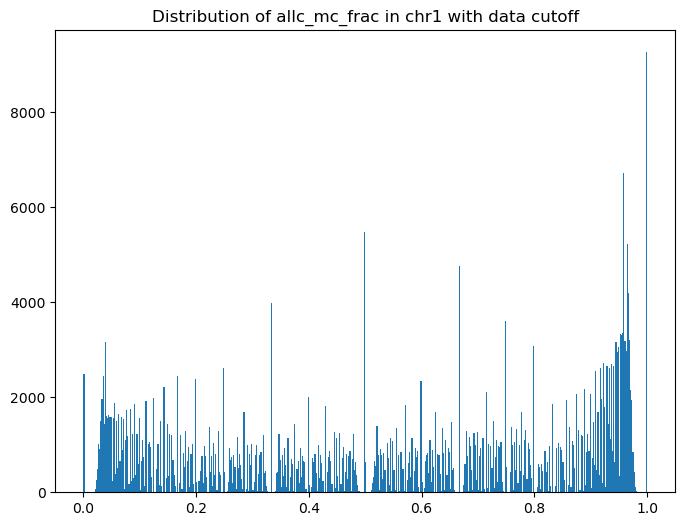

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.hist(flattened_array, bins=500)
plt.title(f"Distribution of allc_mc_frac in chr1 with data cutoff")
plt.show()

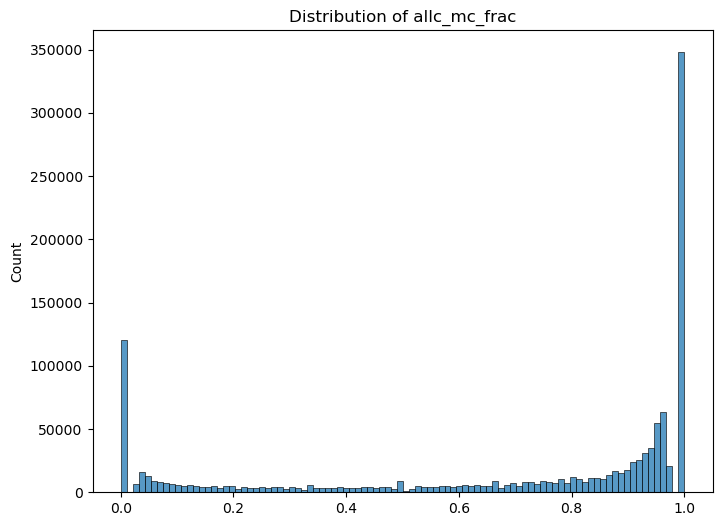

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(flattened_array, kde=False)
plt.title(f"Distribution of allc_mc_frac in chr1")
plt.show()

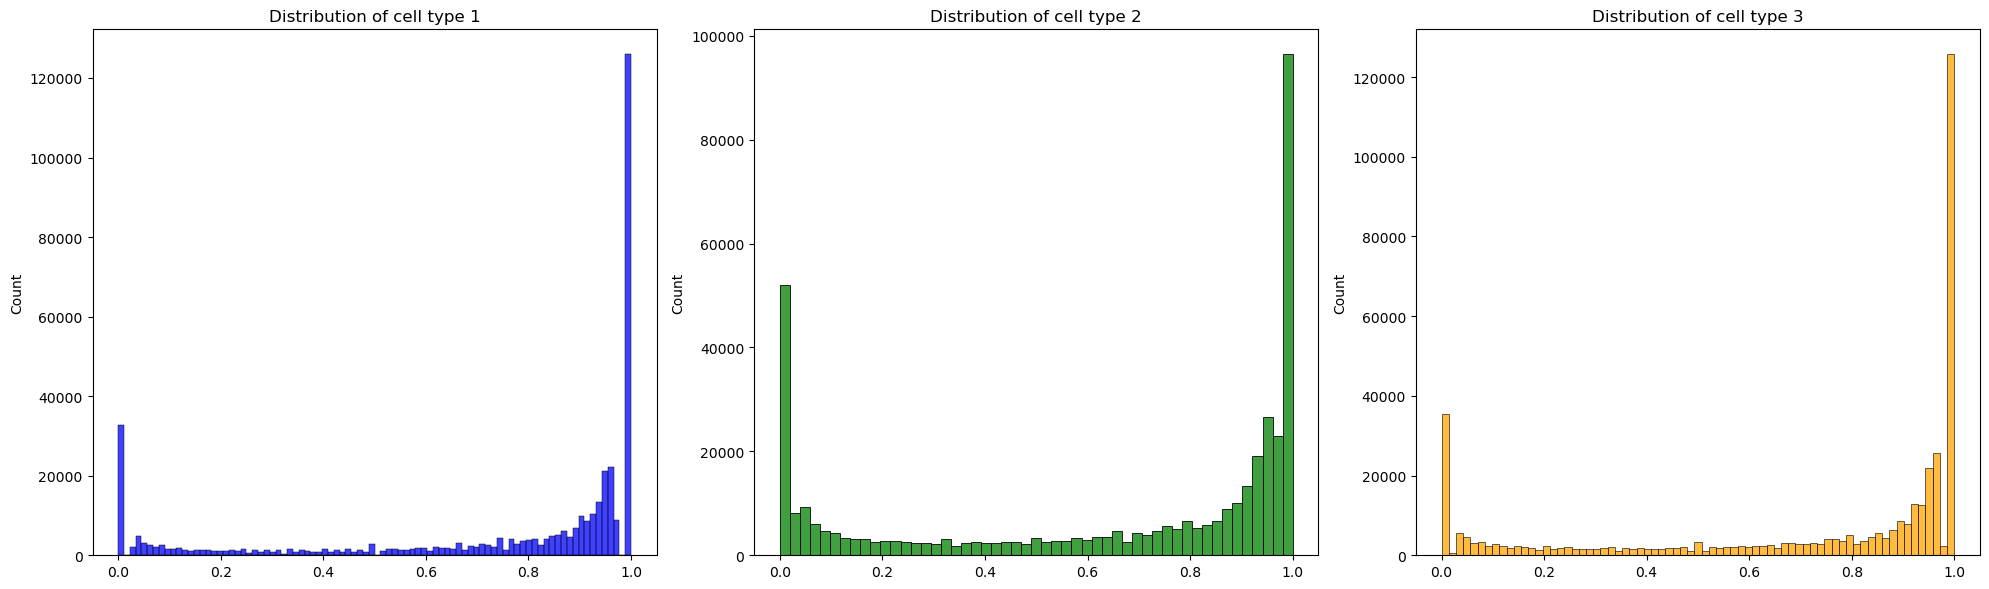

In [39]:
array1 = np.array([arr[0] for arr in values])
array2 = np.array([arr[1] for arr in values])
array3 = np.array([arr[2] for arr in values])

# Create a figure with subplots
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Plot each histogram separately
sns.histplot(array1, kde=False, ax=axs[0], color='blue', label='Array 1')
axs[0].set_title('Distribution of cell type 1')

sns.histplot(array2, kde=False, ax=axs[1], color='green', label='Array 2')
axs[1].set_title('Distribution of cell type 2')

sns.histplot(array3, kde=False, ax=axs[2], color='orange', label='Array 3')
axs[2].set_title('Distribution of cell type 3')

# Adjust layout and display
plt.tight_layout()
plt.show()

### Change to mCplusATAC Dataset

In [4]:
from bolero.tl.model.mc.dataset import mCplusATACDataset
mcatac_dataset = mCplusATACDataset(dataset_path=data_dir, genome="hg38", prefix="allc")

File shuffle is disabled!!!
Loading genome DNA one-hot encoding...


In [6]:
data = mcatac_dataset._read_parquet(chroms='chr1')
data = mcatac_dataset._filter_meta_region_length(dataset=data)
data = mcatac_dataset._compressed_bytes_to_tensor(
    dataset=data,
    concurrency=compressed_bytes_to_tensor_concurrency,
)
# region_bed_path = f'/large_experiments/zhoulab/project/seqmodel/data/HBAtest_mC_multicelltype_hg38/bed/MajorTypeDMR.2500.bed'
region_bed_path = f'/large_experiments/zhoulab/zhoujt/project/seqmodel/240804_region_mc/train_bed/ASC.bed'
standard_length = max(mcatac_dataset.dna_length , mcatac_dataset.signal_length) + 500
region_bed = mcatac_dataset.standard_region_length(region_bed_path, standard_length)
data = mcatac_dataset._generate_regions(
                dataset=data,
                bed=region_bed,
                action_keys=["allc_mc", "allc_cov"],
                max_regions=None,
                concurrency=generate_regions_concurrency,
            )
def _cov_func(data):
        return data.sum(-1).mean(-1)
data = mcatac_dataset._filter_regions(dataset=data, cov_func=_cov_func)

data = mcatac_dataset._get_dna_one_hot(
    dataset=data,
    concurrency=1,
)
mcatac_dataset.train() 
# data = mcatac_dataset._get_bigwig_data(data)
data = mcatac_dataset._get_region_cropper(data)
# data = data.drop_columns(["region"])
data = mcatac_dataset._get_mc_frac(data)

data.schema()

2024-08-12 14:26:15,386	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-12_14-07-04_170785_3330877/logs/ray-data
2024-08-12 14:26:15,386	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(_mc_frac)] -> LimitOperator[limit=1]


Created remote one-hot object at ObjectRef(00ffffffffffffffffffffffffffffffffffffff0100000001e1f505)


Column        Type
------        ----
region        string
dna_one_hot   numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc       numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov      numpy.ndarray(shape=(3, 1000), dtype=float)
jitter        numpy.ndarray(shape=(1,), dtype=int64)
allc_mc_frac  numpy.ndarray(shape=(3, 1000), dtype=float)

In [8]:
# print a batch of data
batch = data.take_batch(3)
regions = batch["region"]
print(regions)

2024-08-12 15:37:09,582	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-12_14-07-04_170785_3330877/logs/ray-data
2024-08-12 15:37:09,582	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(_mc_frac)] -> LimitOperator[limit=3]


['chr1:803701-806041' 'chr1:824902-827242' 'chr1:834654-836994']


In [9]:
# print a batch of data
batch = data.take_batch(1)
regions = batch["region"]

for region in regions:
    chrom, coord_range = region.split(':')
    start_str, end_str = coord_range.split('-')
    start_pos = int(start_str)
    end_pos = int(end_str)
    jitter = batch["jitter"][0,0]
    print(jitter)
    _input_center = (end_pos + start_pos) // 2
    _output_radius = 1000 // 2
    _start = _input_center - _output_radius + jitter
    _end = _start + 1000
    print(_start, _end)

    batch["signal_region"] = [f"{chrom}:{_start}-{_end}"]*len(batch["region"])
print(batch['region'], batch['jitter'], batch['signal_region'])

2024-08-05 21:00:40,004	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-05_20-58-35_049377_3270276/logs/ray-data
2024-08-05 21:00:40,004	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> TaskPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(_mc_frac)->MapBatches(_update_region)] -> LimitOperator[limit=1]


-42
1853469 1854469
['chr1:1852841-1855181'] [[-42]] ['chr1:1853469-1854469']


In [6]:
data = mcatac_dataset._get_cropped_region(data)
data = mcatac_dataset._get_bigwig_data(data)
data = data.drop_columns(["region", "jitter", "signal_region"])

data.schema()

2024-08-07 12:21:21,979	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-07_12-20-46_132165_1590823/logs/ray-data
2024-08-07 12:21:21,980	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(_mc_frac)->MapBatches(_update_region)->MapBatches(FetchRegionBigWigs)] -> TaskPoolMapOperator[MapBatches(_concat_bw_chunks)] -> LimitOperator[limit=1]


Column         Type
------         ----
region         string
dna_one_hot    numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc        numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov       numpy.ndarray(shape=(3, 1000), dtype=float)
jitter         numpy.ndarray(shape=(1,), dtype=int64)
allc_mc_frac   numpy.ndarray(shape=(3, 1000), dtype=float)
signal_region  string
bw_values      numpy.ndarray(shape=(1, 1000), dtype=float)

In [7]:
final_data = mcatac_dataset._norm_bigwig(data)
final_data.schema()

2024-08-07 12:21:38,849	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2024-08-07_12-20-46_132165_1590823/logs/ray-data
2024-08-07 12:21:38,849	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> ActorPoolMapOperator[Filter(region_length_filter)->Map(CompressedBytesToTensor)] -> ActorPoolMapOperator[FlatMap(GenerateRegions)] -> ActorPoolMapOperator[MapBatches(FilterRegions)] -> ActorPoolMapOperator[MapBatches(FetchRegionOneHot)] -> ActorPoolMapOperator[MapBatches(CropLastAxisWithJitter)->MapBatches(_mc_frac)->MapBatches(_update_region)->MapBatches(FetchRegionBigWigs)] -> TaskPoolMapOperator[MapBatches(_concat_bw_chunks)->MapBatches(drop_columns)->MapBatches(_norm_bw)] -> LimitOperator[limit=1]


(MapBatches(_concat_bw_chunks)->MapBatches(drop_columns)->MapBatches(_norm_bw) pid=1591870) /home/zhiwen/seqmodel/bolero/src/bolero/tl/model/mc/dataset.py:398: RuntimeWarning: invalid value encountered in divide
(MapBatches(_concat_bw_chunks)->MapBatches(drop_columns)->MapBatches(_norm_bw) pid=1591870)   bw_normalized = (bw_squeezed - min_vals) / (max_vals - min_vals)


Column        Type
------        ----
dna_one_hot   numpy.ndarray(shape=(4, 1840), dtype=float)
allc_mc       numpy.ndarray(shape=(3, 1000), dtype=float)
allc_cov      numpy.ndarray(shape=(3, 1000), dtype=float)
allc_mc_frac  numpy.ndarray(shape=(3, 1000), dtype=float)
bw_values     numpy.ndarray(shape=(1, 1000), dtype=float)

In [12]:
import torch

x = torch.tensor([1, 2, 3, 4])
A = torch.unsqueeze(x, 0)
B = torch.unsqueeze(x, 1)

A1 = x.unsqueeze(0)
B1 = x.unsqueeze(1)

assert torch.equal(A, A1)
assert torch.equal(B, B1)